<a href="https://colab.research.google.com/github/azurazynn/Data_Analytics_Programming/blob/main/sevilleno_activity_02_data_analytics_programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [19]:
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print("Path to dataset files: ", path)

Using Colab cache for faster access to the 'student-mat-csv' dataset.
Path to dataset files:  /kaggle/input/student-mat-csv


In [20]:
print(os.listdir(path))

['.nfs00000000666d7e8e0000000d', 'student-mat.csv']


In [21]:
file_path = os.path.join(path, "student-mat.csv")
df = pd.read_csv(file_path, sep=";")

In [22]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [23]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [24]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [25]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  395
Number of columns:  33


In [26]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [28]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [29]:
print("Average final grade: ", df["G3"].mean())

Average final grade:  10.415189873417722


In [30]:
print("Minimum final grade: ", df["G3"].min())
print("Maximum final grade: ", df["G3"].max())

Minimum final grade:  0
Maximum final grade:  20


In [31]:
print(df["sex"].value_counts())

sex
F    208
M    187
Name: count, dtype: int64


In [32]:
print(df["school"].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64


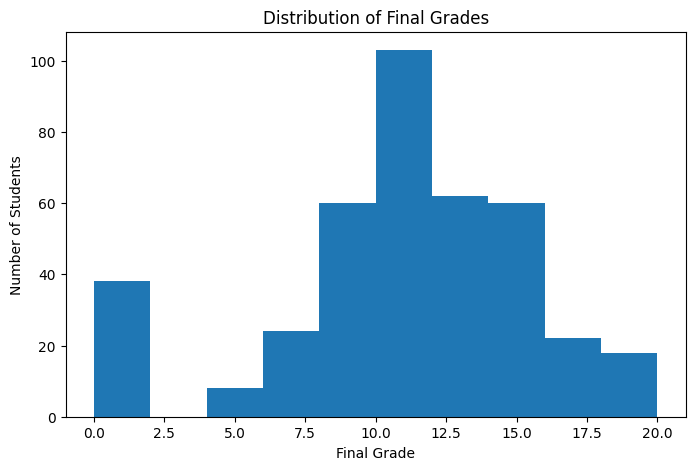

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)

plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()

In [34]:
df.groupby("sex")["G3"].mean()

,G3
sex,
F,9.966346
M,10.914439


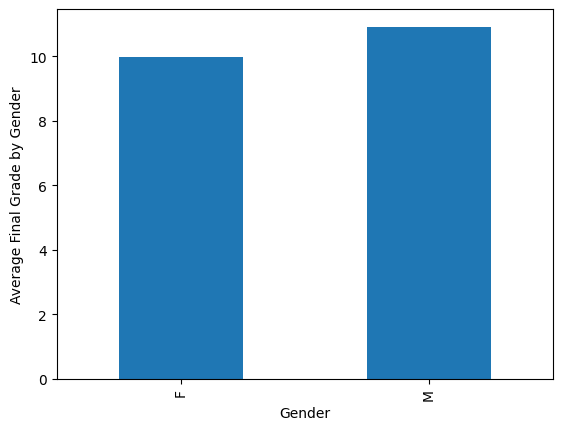

In [35]:
df.groupby("sex")["G3"].mean().plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.ylabel("Average Final Grade by Gender")

plt.show()

**Diagnostic Analytics**

In [36]:
df.groupby("studytime")["G3"].mean()


,G3
studytime,
1,10.047619
2,10.171717
3,11.400000
4,11.259259


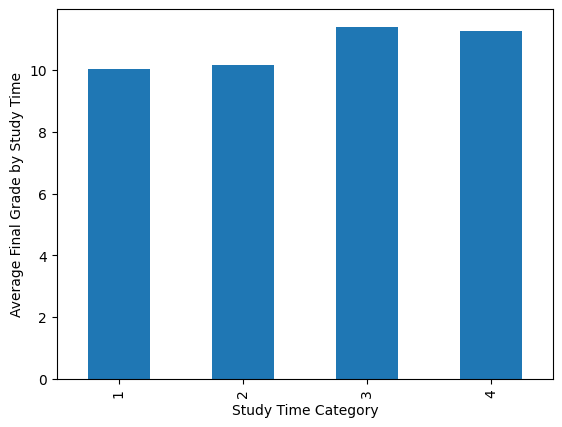

In [37]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")
plt.ylabel("Average Final Grade by Study Time")

plt.show()


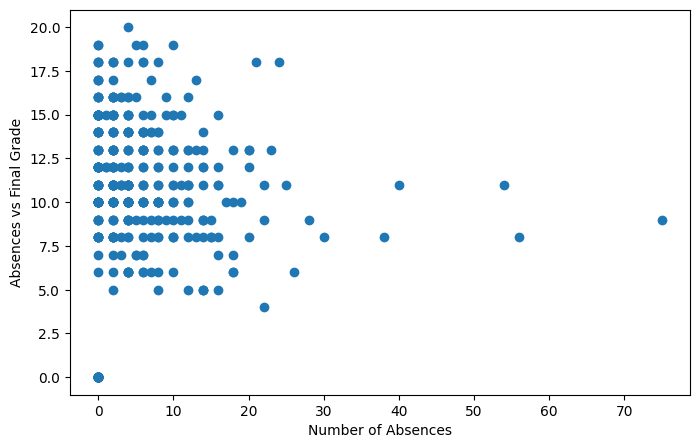

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.ylabel("Absences vs Final Grade")

plt.show()

In [39]:
print(df["absences"].corr(df["G3"]))

0.03424731615006931


**Prepare for Predictive Analytics**

In [40]:
df["pass"] = (df["G3"]>=10).astype(int)

In [41]:
print(df["pass"].value_counts())

pass
1    265
0    130
Name: count, dtype: int64


In [42]:
features = [
    "age",
    "studytime",
    "failures",
    "G1",
    "G2"
]

x = df[features]
y = df["pass"]

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [45]:
y_pred = model.predict(x_test)

print(y_pred)

[1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0
 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 1 1 0 1 1]


In [46]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8860759493670886


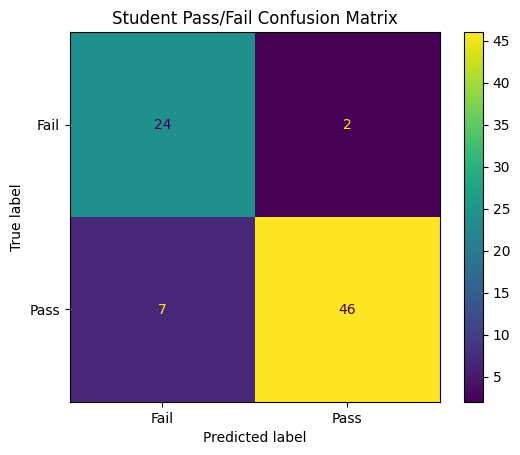

In [47]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Student Pass/Fail Confusion Matrix")
plt.show()

**Prediction Results Table**

In [49]:
results = x_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted
305,18,2,1,14,12,1,1
225,18,2,1,9,8,0,0
237,16,1,0,13,12,1,1
318,17,3,0,11,11,1,1
182,17,2,0,16,17,1,1
94,15,4,0,11,13,1,1
34,16,1,0,12,14,1,1
307,19,1,1,8,9,0,1
33,15,2,0,8,10,1,1
36,15,3,0,15,16,1,1


**Prescriptive Analytics**

In [51]:
results["Risk"] = results["Predicted"].map({
    0: "At Risk",
    1: "Likeley to Pass"
})

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted,Risk
305,18,2,1,14,12,1,1,Likeley to Pass
225,18,2,1,9,8,0,0,At Risk
237,16,1,0,13,12,1,1,Likeley to Pass
318,17,3,0,11,11,1,1,Likeley to Pass
182,17,2,0,16,17,1,1,Likeley to Pass
94,15,4,0,11,13,1,1,Likeley to Pass
34,16,1,0,12,14,1,1,Likeley to Pass
307,19,1,1,8,9,0,1,Likeley to Pass
33,15,2,0,8,10,1,1,Likeley to Pass
36,15,3,0,15,16,1,1,Likeley to Pass


In [52]:
results["Risk"] = results["Predicted"].map({
    0: "Prioritize for academic intervention",
    1: "Continue regular monitoring"
})

results.head(10)

,age,studytime,failures,G1,G2,Actual,Predicted,Risk
305,18,2,1,14,12,1,1,Continue regular monitoring
225,18,2,1,9,8,0,0,Prioritize for academic intervention
237,16,1,0,13,12,1,1,Continue regular monitoring
318,17,3,0,11,11,1,1,Continue regular monitoring
182,17,2,0,16,17,1,1,Continue regular monitoring
94,15,4,0,11,13,1,1,Continue regular monitoring
34,16,1,0,12,14,1,1,Continue regular monitoring
307,19,1,1,8,9,0,1,Continue regular monitoring
33,15,2,0,8,10,1,1,Continue regular monitoring
36,15,3,0,15,16,1,1,Continue regular monitoring


In [53]:
probabilities = model.predict_proba(x_test)

results["Probability_of_Failing"]=probabilities[:, 0]

results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

,age,studytime,failures,G1,G2,Actual,Predicted,Risk,Probability_of_Failing
255,17,1,1,7,9,0,0,Prioritize for academic intervention,1.000000
67,16,4,0,7,7,0,0,Prioritize for academic intervention,1.000000
92,16,2,0,7,6,0,0,Prioritize for academic intervention,1.000000
1,17,2,0,5,5,0,0,Prioritize for academic intervention,1.000000
188,17,2,0,8,7,0,0,Prioritize for academic intervention,1.000000
383,19,1,1,6,5,0,0,Prioritize for academic intervention,1.000000
248,18,2,1,3,5,0,0,Prioritize for academic intervention,1.000000
118,17,2,1,9,7,0,0,Prioritize for academic intervention,1.000000
332,18,2,0,7,0,0,0,Prioritize for academic intervention,1.000000
370,19,2,2,7,7,0,0,Prioritize for academic intervention,1.000000


In [56]:
priority_students=results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

priority_students

,age,studytime,failures,G1,G2,Actual,Predicted,Risk,Probability_of_Failing
255,17,1,1,7,9,0,0,Prioritize for academic intervention,1.000000
67,16,4,0,7,7,0,0,Prioritize for academic intervention,1.000000
92,16,2,0,7,6,0,0,Prioritize for academic intervention,1.000000
1,17,2,0,5,5,0,0,Prioritize for academic intervention,1.000000
188,17,2,0,8,7,0,0,Prioritize for academic intervention,1.000000
383,19,1,1,6,5,0,0,Prioritize for academic intervention,1.000000
248,18,2,1,3,5,0,0,Prioritize for academic intervention,1.000000
118,17,2,1,9,7,0,0,Prioritize for academic intervention,1.000000
332,18,2,0,7,0,0,0,Prioritize for academic intervention,1.000000
370,19,2,2,7,7,0,0,Prioritize for academic intervention,1.000000
